# Here lies a Scientific-Oriented Data Analysis of an Insurance Dataset

### 1. We Import all Dependencies Needed

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

### 2. We Extract the Data from a CSV File

In [2]:
URL_PATH = os.getcwd() + "\\Datasets_option1\\insurance.csv"

insurance_df = pd.read_csv(URL_PATH)

insurance_df.head(1)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924


### 3. Let's Analyze the Dataset

In [3]:
insurance_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In terms of data types, everything seems ok.

In [4]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
insurance_df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In terms of rows count, everything seems ok too.

### 4. The Dataset is Ready. It's time to define variable types

In [6]:
target = "charges"

categorical_features = ["sex", "smoker", "region"]
numerical_features = ["age", "bmi", "children"]

X = insurance_df.drop(columns=target)
y = insurance_df[target]

### 5. Descriptive Analysis - What happened?

#### 5.1 Distribution of charges

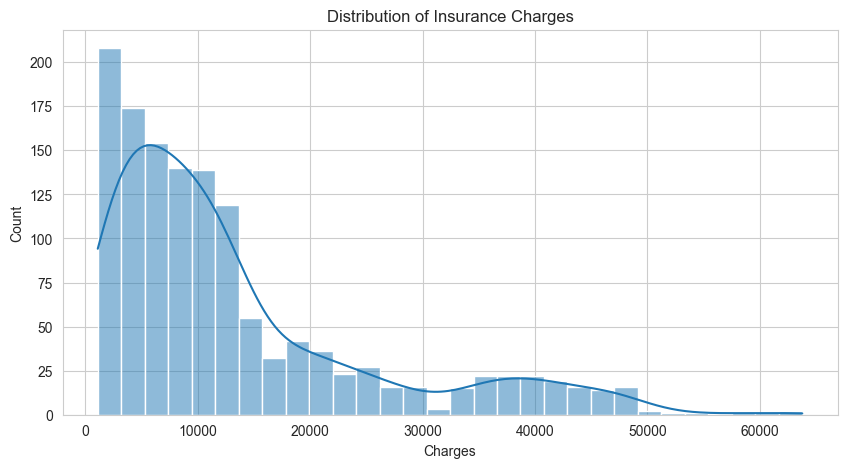

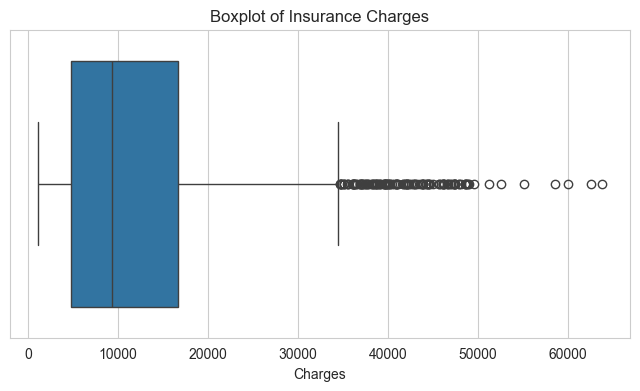

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(insurance_df["charges"], bins=30, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=insurance_df["charges"])
plt.title("Boxplot of Insurance Charges")
plt.xlabel("Charges")
plt.show()

The distribution of insurance charges is right-skewed, with most observations concentrated at lower values and a long tail of high-cost outliers

#### 5.2 Distribution of numerical variables

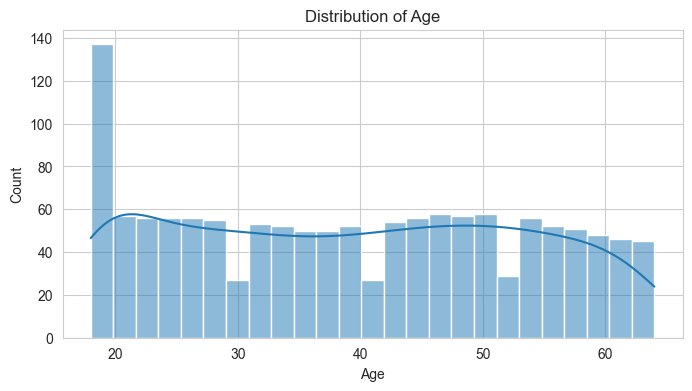

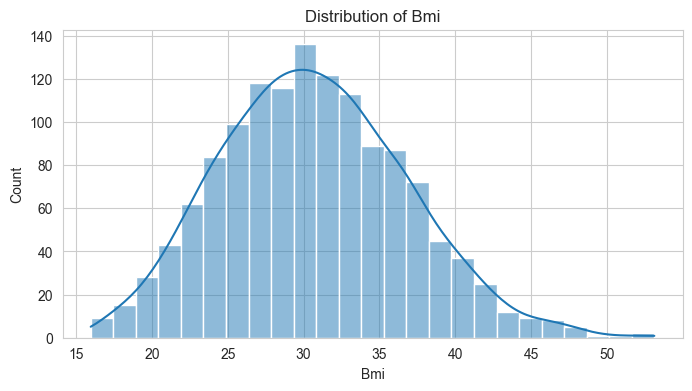

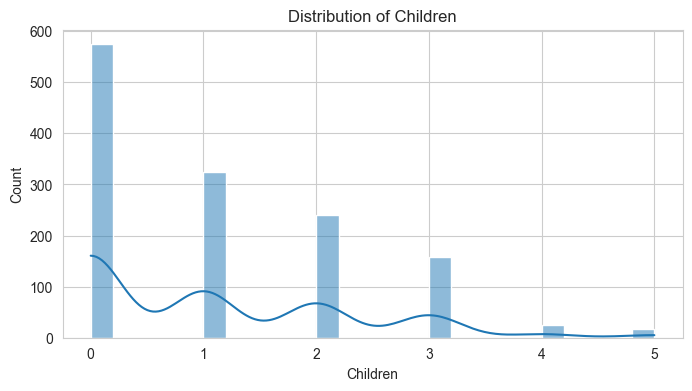

In [8]:
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(insurance_df[col], bins=25, kde=True)
    plt.title(f"Distribution of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.show()

age: a concentrated number of people under 20
bmi: The BMI distribution is approximately normal, centered around 30, with a slight right skew.
children: The number of children is a discrete, right-skewed distribution, with most individuals having 0 or 1 child

#### 5.3 Categorical breakdown

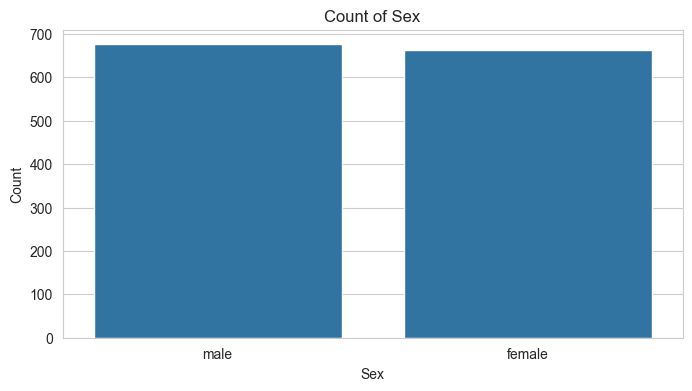

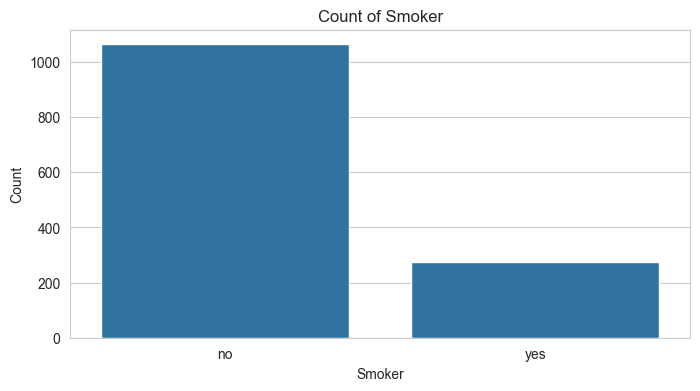

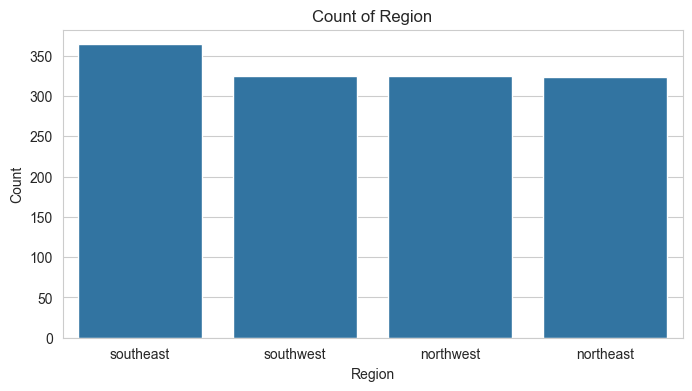

In [9]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=insurance_df, x=col, order=insurance_df[col].value_counts().index)
    plt.title(f"Count of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")
    plt.show()

there are slightly more male than female, more non-smokers, and more southeast people within this dataset.

#### 5.4 Average charges by category

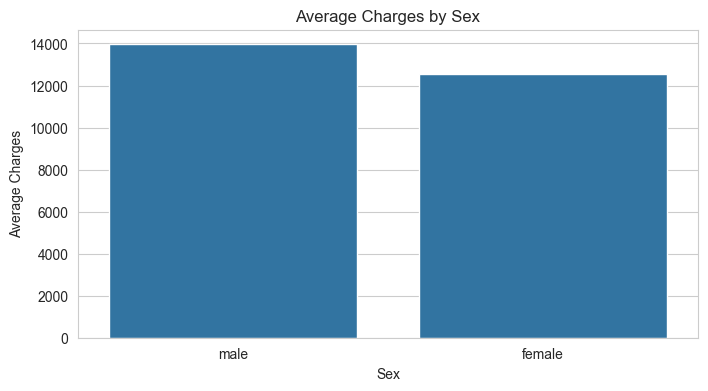

,avg_charges
sex,
male,13956.751178
female,12569.578844


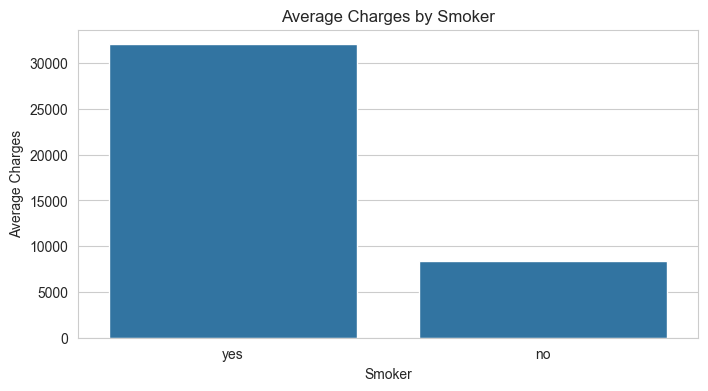

,avg_charges
smoker,
yes,32050.231832
no,8434.268298


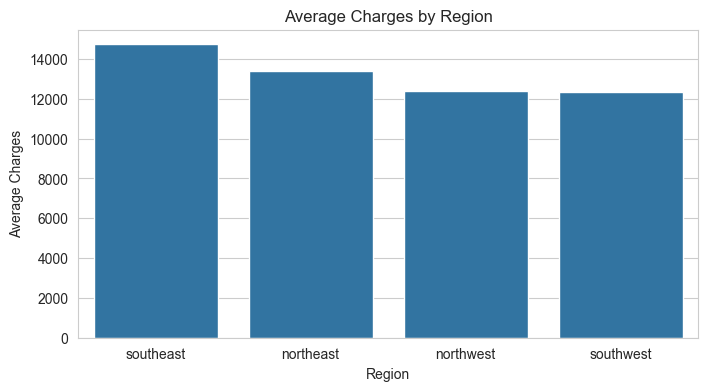

,avg_charges
region,
southeast,14735.411438
northeast,13406.384516
northwest,12417.575374
southwest,12346.937377


In [10]:
for col in categorical_features:
    avg_charge = insurance_df.groupby(col)["charges"].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=avg_charge.index, y=avg_charge.values)
    plt.title(f"Average Charges by {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Average Charges")
    plt.show()
    
    display(avg_charge.to_frame(name="avg_charges"))

#### 5.5 Charges by smoker status

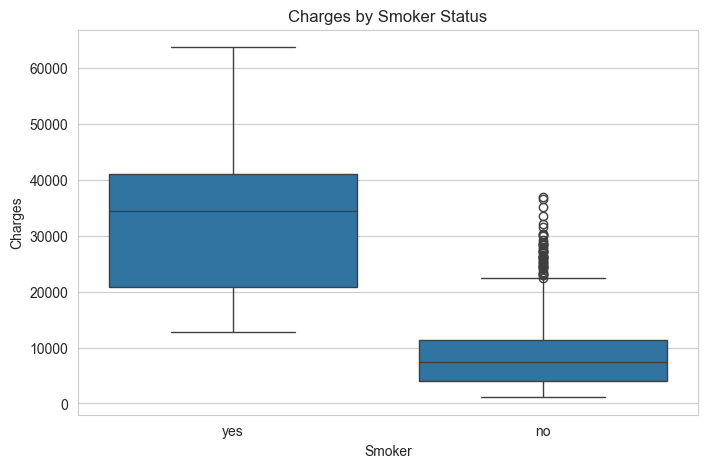

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=insurance_df, x="smoker", y="charges")
plt.title("Charges by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

Smoking seems to strongly increase the insurance charges.

#### 5.6 Age, BMI, and charges

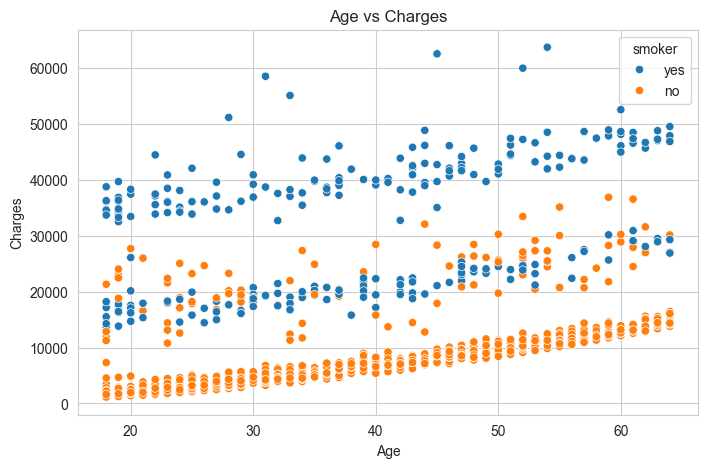

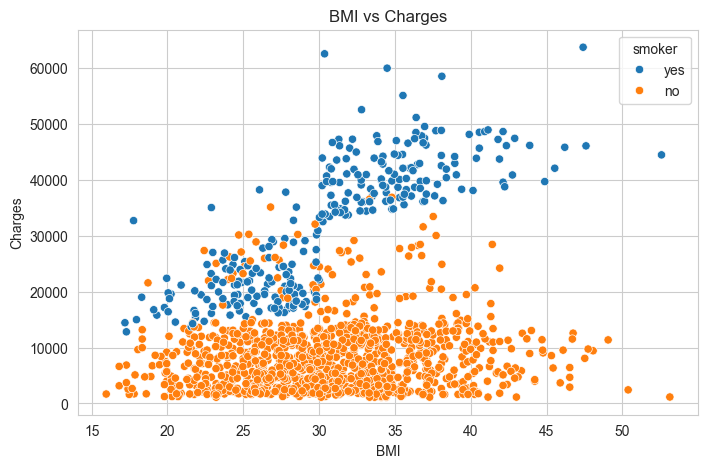

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=insurance_df, x="age", y="charges", hue="smoker")
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=insurance_df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

BMI alone doesn't seem to be relevant to predict future chareges. But does when combine with people who smoke.

### 6. Diagnostic Analysis - Why is it happening?

#### 6.1 Correlation heatmap

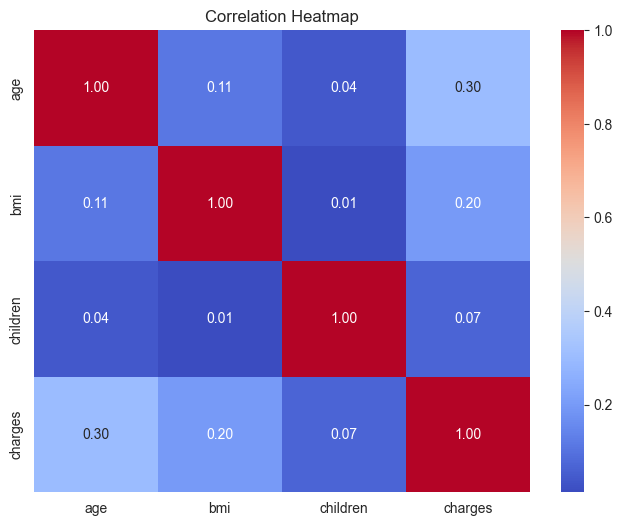

In [13]:
numeric_df = insurance_df[numerical_features + ["charges"]]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Here, the strongest correlation seems to be age and charges. We can imagine that as a person gets old, the higher the charges.

#### 6.2 Interaction: smoker + BMI

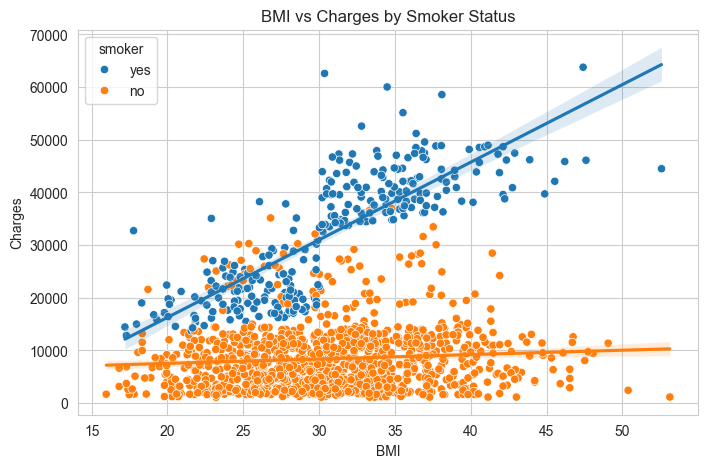

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=insurance_df, x="bmi", y="charges", hue="smoker")
sns.regplot(data=insurance_df[insurance_df["smoker"] == "yes"], x="bmi", y="charges", scatter=False)
sns.regplot(data=insurance_df[insurance_df["smoker"] == "no"], x="bmi", y="charges", scatter=False)
plt.title("BMI vs Charges by Smoker Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

#### 6.3 Charges by age groups

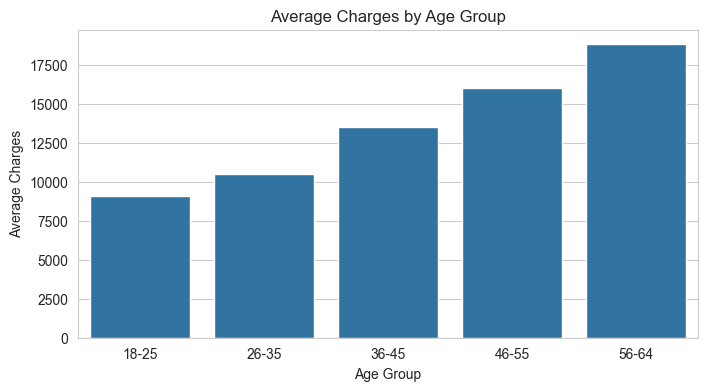

,avg_charges
age_group,
18-25,9087.015807
26-35,10495.163047
36-45,13493.485247
46-55,15986.900310
56-64,18795.993816


In [15]:
insurance_df["age_group"] = pd.cut(
    insurance_df["age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-64"]
)

avg_age_group = insurance_df.groupby("age_group")["charges"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_age_group.index, y=avg_age_group.values)
plt.title("Average Charges by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Charges")
plt.show()

display(avg_age_group.to_frame(name="avg_charges"))

#### 6.4 Charges by BMI categories

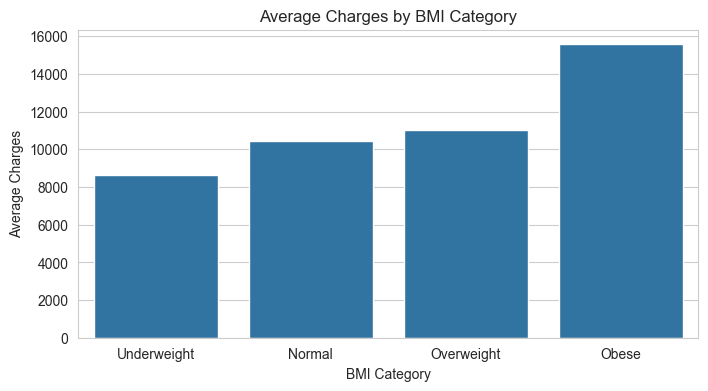

,avg_charges
bmi_category,
Underweight,8657.620652
Normal,10435.440719
Overweight,10997.803881
Obese,15560.926321


In [16]:
insurance_df["bmi_category"] = pd.cut(
    insurance_df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

avg_bmi_group = insurance_df.groupby("bmi_category")["charges"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=avg_bmi_group.index, y=avg_bmi_group.values)
plt.title("Average Charges by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Charges")
plt.show()

display(avg_bmi_group.to_frame(name="avg_charges"))

#### 6.5 Correlation with Categorical Features

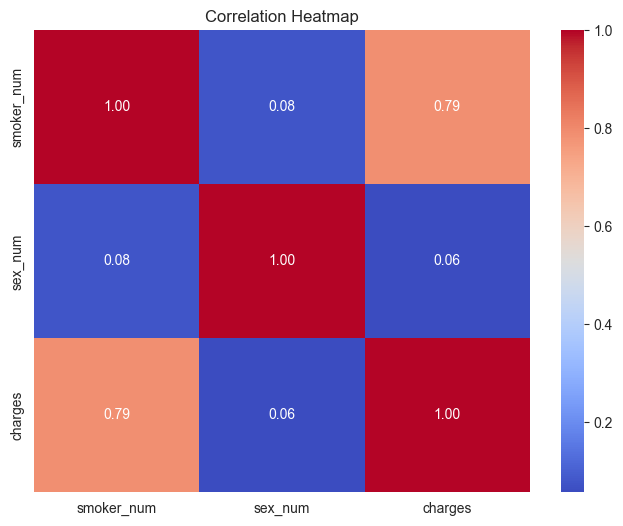

In [32]:
insurance_df["smoker_num"] = insurance_df["smoker"].map({"yes":1, "no":0})
insurance_df["sex_num"] = insurance_df["sex"].map({"male":1, "female":0})
cat_df = insurance_df[["smoker_num", "sex_num", "charges"]]

plt.figure(figsize=(8, 6))
sns.heatmap(cat_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The boolean feature about smoking is positively correlated with charges, while the sex seems irrelevant to predict charges.

#### 6.6 Smoker impact summary

In [18]:
smoker_summary = insurance_df.groupby("smoker")["charges"].agg(["mean", "median", "min", "max", "std", "count"])
display(smoker_summary)

smoker_diff = (
    insurance_df.groupby("smoker")["charges"].mean()["yes"]
    - insurance_df.groupby("smoker")["charges"].mean()["no"]
)

print(f"Difference in average charges between smokers and non-smokers: {smoker_diff:,.2f}")

,mean,median,min,max,std,count
smoker,,,,,,
no,8434.268298,7345.40530,1121.8739,36910.60803,5993.781819,1064
yes,32050.231832,34456.34845,12829.4551,63770.42801,11541.547176,274


Difference in average charges between smokers and non-smokers: 23,615.96


### 7. Prescriptive Analysis - What should we do?

#### 7.1 Simple business recommendations from data

In [19]:
segment_summary = insurance_df.groupby(["smoker", "bmi_category", "age_group"])["charges"].mean().reset_index()
segment_summary = segment_summary.sort_values(by="charges", ascending=False)

display(segment_summary.head(15))

,smoker,bmi_category,age_group,charges
37,yes,Obese,56-64,47281.270410
36,yes,Obese,46-55,44973.416460
35,yes,Obese,36-45,41952.819242
34,yes,Obese,26-35,40164.649921
33,yes,Obese,18-25,36252.908320
32,yes,Overweight,56-64,28642.792333
27,yes,Normal,56-64,25513.963863
30,yes,Overweight,36-45,24334.307077
31,yes,Overweight,46-55,24073.743375
26,yes,Normal,46-55,23126.486235


#### 7.2 High-risk profiles

In [20]:
high_risk = insurance_df[
    (insurance_df["smoker"] == "yes") &
    (insurance_df["bmi"] >= 30)
]

print("High-risk subgroup shape:", high_risk.shape)
display(high_risk[["age", "sex", "bmi", "children", "smoker", "region", "charges"]].head())

print("Average charges in high-risk subgroup:", round(high_risk["charges"].mean(), 2))
print("Overall average charges:", round(insurance_df["charges"].mean(), 2))

High-risk subgroup shape: (145, 9)


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


Average charges in high-risk subgroup: 41557.99
Overall average charges: 13270.42


#### 7.3 Prescriptive conclusions

In [21]:
avg_charges_total = insurance_df["charges"].mean()
avg_charges_smoker = insurance_df.groupby("smoker")["charges"].mean()
avg_charges_bmi = insurance_df.groupby("bmi_category")["charges"].mean()
avg_charges_age = insurance_df.groupby("age_group")["charges"].mean()

display(avg_charges_total, avg_charges_smoker, avg_charges_bmi, avg_charges_age)

np.float64(13270.422265141257)

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

bmi_category
Underweight     8657.620652
Normal         10435.440719
Overweight     10997.803881
Obese          15560.926321
Name: charges, dtype: float64

age_group
18-25     9087.015807
26-35    10495.163047
36-45    13493.485247
46-55    15986.900310
56-64    18795.993816
Name: charges, dtype: float64

In [43]:
print("PRESCRIPTIVE INSIGHTS")
print(
"Based on the analysis, preventive actions should primarily target smokers, as they generate significantly higher average charges compared to non-smokers. In parallel, wellness and health \n\
improvement programs should focus on individuals classified as obese, especially when combined with smoking behavior, as this segment represents the highest cost burden. Age segmentation \n\
also plays a key role, with charges increasing steadily across age groups, suggesting the need for differentiated pricing strategies and tailored risk management approaches. Overall, rather \n\
than applying uniform policies, insurers should prioritize targeted interventions toward high-cost segments to improve both cost efficiency and health outcomes."
)

PRESCRIPTIVE INSIGHTS
Based on the analysis, preventive actions should primarily target smokers, as they generate significantly higher average charges compared to non-smokers. In parallel, wellness and health 
improvement programs should focus on individuals classified as obese, especially when combined with smoking behavior, as this segment represents the highest cost burden. Age segmentation 
also plays a key role, with charges increasing steadily across age groups, suggesting the need for differentiated pricing strategies and tailored risk management approaches. Overall, rather 
than applying uniform policies, insurers should prioritize targeted interventions toward high-cost segments to improve both cost efficiency and health outcomes.


### 8. Predictive Analysis - What is likely to happen?

#### 8.1 Train/test split and preprocessing

In [23]:
X_model = insurance_df.drop(columns=["charges", "age_group", "bmi_category"], errors="ignore")
y_model = insurance_df["charges"]

categorical_model_features = ["sex", "smoker", "region"]
numerical_model_features = ["age", "bmi", "children"]

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_model_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_model_features)
    ]
)

#### 8.2 Baseline model: Linear Regression

In [24]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("LINEAR REGRESSION RESULTS")
print("MAE :", round(mean_absolute_error(y_test, y_pred_lr), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 2))
print("R²  :", round(r2_score(y_test, y_pred_lr), 4))

LINEAR REGRESSION RESULTS
MAE : 4181.19
RMSE: 5796.28
R²  : 0.7836


#### 8.3 More powerful model: Random Forest

In [25]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("RANDOM FOREST RESULTS")
print("MAE :", round(mean_absolute_error(y_test, y_pred_rf), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2))
print("R²  :", round(r2_score(y_test, y_pred_rf), 4))

RANDOM FOREST RESULTS
MAE : 2461.44
RMSE: 4405.14
R²  : 0.875


#### 8.4 Model comparison

In [26]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

display(comparison_df.sort_values(by="R2", ascending=False))

,Model,MAE,RMSE,R2
1,Random Forest,2461.438427,4405.141137,0.875005
0,Linear Regression,4181.194474,5796.284659,0.783593


#### 8.5 Actual vs predicted graph

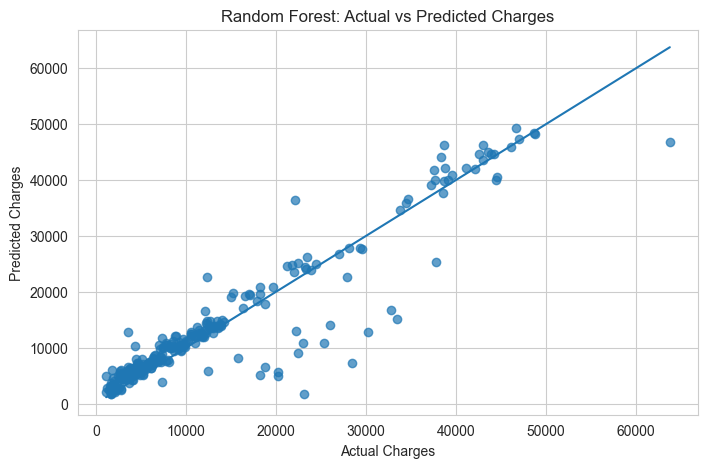

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest: Actual vs Predicted Charges")
plt.show()

#### 8.6 Residual analysis

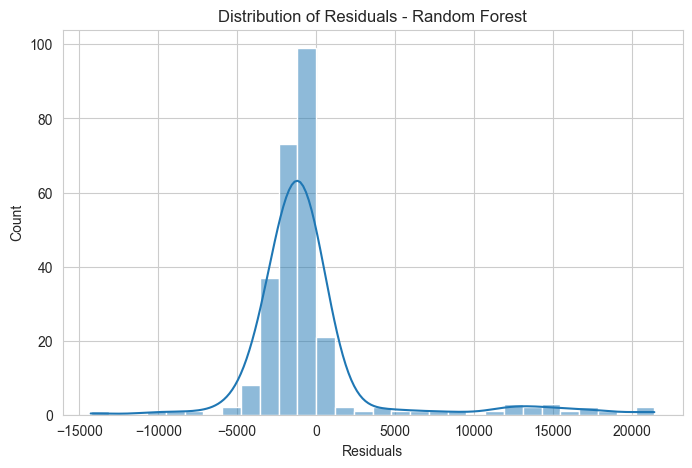

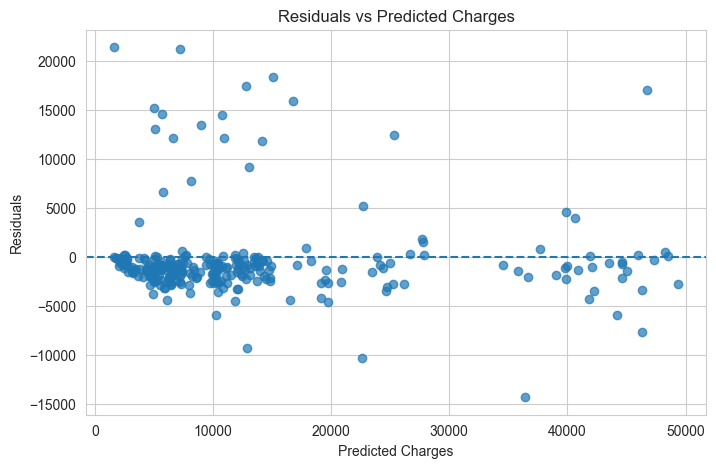

In [28]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8, 5))
sns.histplot(residuals_rf, bins=30, kde=True)
plt.title("Distribution of Residuals - Random Forest")
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Charges")
plt.show()

#### 8.7 Predict the charge of a new person

In [29]:
new_customer = pd.DataFrame([{
    "age": 19,
    "sex": "female",
    "bmi": 27.9,
    "children": 0,
    "smoker": "yes",
    "region": "southwest"
}])

predicted_charge = rf_pipeline.predict(new_customer)[0]
print(f"Predicted charges for new customer: {predicted_charge:,.2f} $")

Predicted charges for new customer: 17,267.16 $


### 9. Conclusion

In [30]:
best_model_name = comparison_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
best_model_r2 = comparison_df.sort_values(by="R2", ascending=False).iloc[0]["R2"]

print("FINAL ANALYSIS SUMMARY")
print()
print("1. DESCRIPTIVE")
print("- The dataset describes insurance charges across individuals with demographic and health-related attributes.")
print("- Charges are highly dispersed, with some customers generating much larger costs than others.")
print()
print("2. DIAGNOSTIC")
print("- Smoking is the strongest driver of high charges.")
print("- BMI and age also increase charges, especially when combined with smoking.")
print("- Region and sex have a weaker impact than smoker status.")
print()
print("3. PRESCRIPTIVE")
print("- Focus health prevention strategies on smokers and obese policyholders.")
print("- Use customer segmentation for pricing and targeted health management.")
print("- Build differentiated intervention policies for high-risk profiles.")
print()
print("4. PREDICTIVE")
print(f"- The best-performing model in this notebook is: {best_model_name}")
print(f"- Its R² on the test set is: {best_model_r2:.4f}")
print("- This model can estimate future medical charges from customer characteristics.")

FINAL ANALYSIS SUMMARY

1. DESCRIPTIVE
- The dataset describes insurance charges across individuals with demographic and health-related attributes.
- Charges are highly dispersed, with some customers generating much larger costs than others.

2. DIAGNOSTIC
- Smoking is the strongest driver of high charges.
- BMI and age also increase charges, especially when combined with smoking.
- Region and sex have a weaker impact than smoker status.

3. PRESCRIPTIVE
- Focus health prevention strategies on smokers and obese policyholders.
- Use customer segmentation for pricing and targeted health management.
- Build differentiated intervention policies for high-risk profiles.

4. PREDICTIVE
- The best-performing model in this notebook is: Random Forest
- Its R² on the test set is: 0.8750
- This model can estimate future medical charges from customer characteristics.
